# R04 — Movement Effectiveness

**Goal:** Measure how well our robot dodges enemy fire.

The opponent's hit rate against us tells us how well our movement (wave-surfing)
system is working. Lower opponent hit rate = better dodging. Competitive wave
surfers keep opponent hit rates below 8–10%.

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_scores, add_opponent_names
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

scores = add_opponent_names(load_local_scores())
print(f'Loaded {len(scores):,} score rows')

Indexed 96 ticks.csv files across 6 distinct robots from 1 root(s).
Selected 6 robots × ~100 battles = 96 (battle, robot) pairs to load.


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 96 scores.csv files → 3,360 rows × 17 cols, 6 robots (~0.6 MB)
Loaded 1,680 score rows


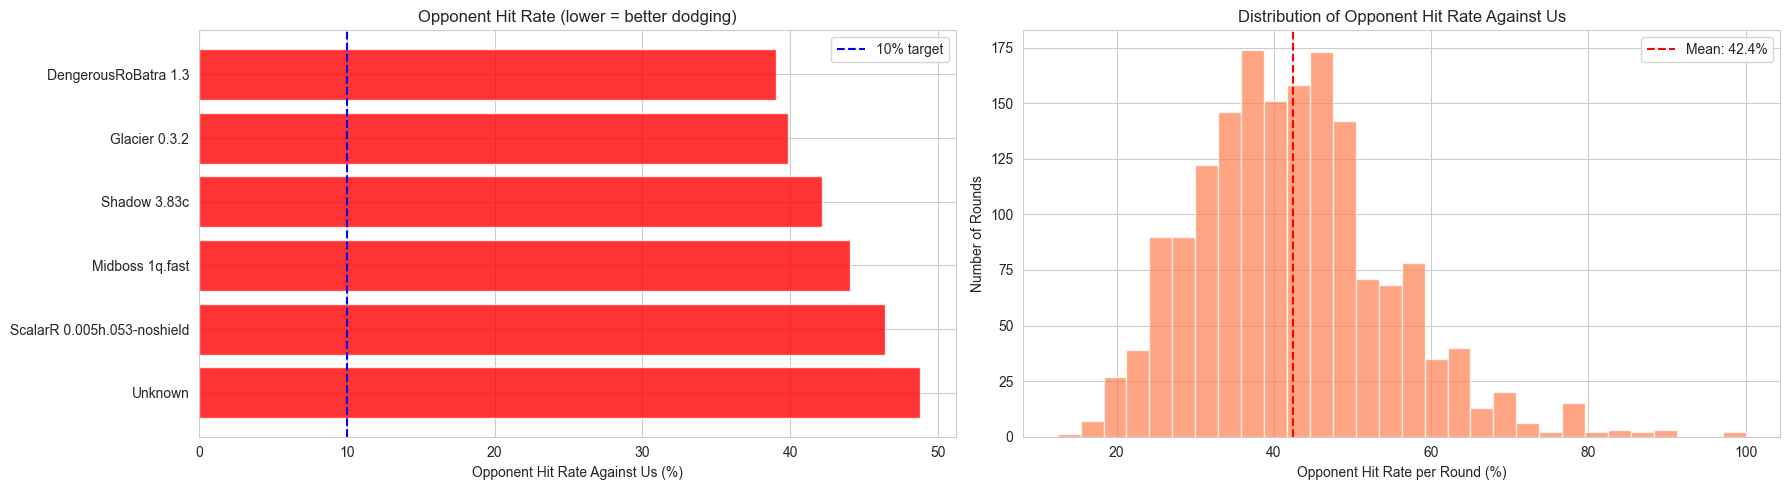


Overall mean opponent hit rate: 42.4%
Hardest to dodge: Unknown (48.8%)
Easiest to dodge: DengerousRoBatra 1.3 (39.0%)


In [2]:
# Opponent hit rate against us = inverse of dodge effectiveness
dodge = scores.groupby('opponent_name')['opponent_hit_rate'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(dodge)*0.5)))

ax = axes[0]
colors = ['red' if x > 0.15 else 'orange' if x > 0.10 else 'green' for x in dodge.values]
ax.barh(dodge.index, dodge.values * 100, color=colors, alpha=0.8)
ax.set_xlabel('Opponent Hit Rate Against Us (%)')
ax.set_title('Opponent Hit Rate (lower = better dodging)')
ax.axvline(x=10, color='blue', linestyle='--', label='10% target')
ax.legend()

ax = axes[1]
ax.hist(scores['opponent_hit_rate'].dropna() * 100, bins=30, color='coral', alpha=0.7, edgecolor='white')
ax.set_xlabel('Opponent Hit Rate per Round (%)')
ax.set_ylabel('Number of Rounds')
ax.set_title('Distribution of Opponent Hit Rate Against Us')
mean_ohr = scores['opponent_hit_rate'].mean()*100
ax.axvline(x=mean_ohr, color='red', linestyle='--', label=f'Mean: {mean_ohr:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\nOverall mean opponent hit rate: {mean_ohr:.1f}%')
print(f'Hardest to dodge: {dodge.index[0]} ({dodge.iloc[0]*100:.1f}%)')
print(f'Easiest to dodge: {dodge.index[-1]} ({dodge.iloc[-1]*100:.1f}%)')